In [31]:
import torch
from xml.etree import ElementTree as ET
import albumentations as A
from albumentations.pytorch.transforms import ToTensorV2
from pathlib import Path
import glob
import numpy as np
from PIL import Image
import torchvision
from tqdm import tqdm
from torch import nn
import shutil
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
import matplotlib.patches as patches
import os

In [2]:
class_dict = {"king":0, "jack":1, "ace":2, "ten":3, "nine":4, "queen":5}
class_dict_inv = dict(zip(class_dict.values(), class_dict.keys()))

In [3]:
def get_xml_data(image_name, root, class_dict, xml_prefix="/xmls/"):
    filename = image_name.split("/")[-1].split(".")[0]
    #print(str(root),  xml_prefix, filename + ".xml")
    tree = ET.parse(str(root) + xml_prefix + filename[6:] + ".xml")
    treeroot = tree.getroot()
    bboxes = []
    for member in treeroot.findall("object"):
        res = []
        res.append(int(member.find('bndbox').find('xmin').text))
        res.append(int(member.find('bndbox').find('ymin').text))
        res.append(int(member.find('bndbox').find('xmax').text))
        res.append(int(member.find('bndbox').find('ymax').text))
        name = member.find('name').text
        res.append(int(class_dict[name]))
        # you need: xmin ymin xmax ymax, class in dict
        # то есть res выглядит как [xmin, ymin, xmax, ymax, class]
        # всё в int
        bboxes.append(res)
    return bboxes
    
class PascalDataset(torch.utils.data.Dataset):
    def __init__(self, *, transform, root="dataset", train=True, seed=42, resize = (448, 448), S=7, B=2, C=6):
        self.root = Path(root)
        self.resize = resize
        self.transform = transform
        assert self.root.is_dir(), f"No data at `{root}`"
        self.filenames = np.array(glob.glob(root + "/images/*"))
        
        with open(str(self.root) + "/class_dict", "r") as f:
            self.class_dict = eval(f.readline())
        self.class_dict_inv = {v: k for k, v in self.class_dict.items()}
        np.random.seed(seed)
        permutation = np.random.permutation(len(self.filenames))
        self.C = C
        self.B = B
        self.S = S
        
        if train:
            self.filenames = self.filenames[
                permutation[: int(len(self.filenames) * 0.9)]
            ].tolist()
        else:
            self.filenames = self.filenames[
                permutation[int(len(self.filenames) * 0.9) :]
            ].tolist()
    
    def __getitem__(self, idx):
        fname = self.filenames[idx]
        image, bboxes = self.__get_raw_item__(idx, fname)
        if self.transform:
            image = self.transform(image)
            
        #cells processing
        cell = np.zeros((self.S, self.S, self.C + 5 * self.B))
        for bbox in bboxes:
            x_center, y_center, w, h, cls = bbox
            x_index, y_index = int(x_center * self.S), int(y_center * self.S)
            x_cell, y_cell, w_cell, h_cell = self.S * x_center - x_index, self.S * y_center - y_index, self.S * w, self.S * h
            if cell[x_index, y_index, self.C] == 0:
                #confidence
                cell[x_index, y_index, self.C] = 1
                
                #bbox coord
                bbox_coord = torch.tensor([x_cell, y_cell, w_cell, h_cell])
                cell[x_index, y_index, self.C + 1: self.C + 5] = bbox_coord
                
                #class in one hot 
                cell[x_index, y_index, cls] = 1
        return image.float(), torch.tensor(cell).float()

    def __get_raw_item__(self, idx, fname):
        image = Image.open(fname).convert('RGB')
        #print(fname, self.root, self.class_dict)
        bboxes = get_xml_data(fname, self.root, self.class_dict)
        image_array = np.array(image)
        H, W, C = image_array.shape
        normalized_bboxes = []
        #min_x, min_y, max_x, max_y, cls  ->  norm_min_x, norm_min_y, norm_max_x, norm_max_y  ->  norm_x_center, norm_y_center, norm_w, norm_h
        
        for bbox in bboxes:
            normalized_bbox = []
            normalized_bbox.append(int(bbox[0] / W * self.resize[0]))
            normalized_bbox.append(int(bbox[1] / H * self.resize[1]))
            normalized_bbox.append(int(bbox[2] / W * self.resize[0]))
            normalized_bbox.append(int(bbox[3] / H * self.resize[1]))
            normalized_bbox.append(bbox[-1])
            #print(normalized_bbox)
            x_center, y_center, w, h = corners_to_midpoints(normalized_bbox[:-1])
            #print(x_center, y_center, w, h, cls)
            normalized_bbox = [x_center / self.resize[0], y_center / self.resize[1], w / self.resize[0], h / self.resize[1], bbox[-1]]
            normalized_bboxes.append(normalized_bbox)
        return image, normalized_bboxes

    def __len__(self):
        return len(self.filenames)

In [4]:
mean = (0.485, 0.456, 0.406)
std = (0.229, 0.224, 0.225)
image_size = (448, 448)

train_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.RandomGrayscale(),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std)
])

test_transform = transforms.Compose([
    transforms.Resize(image_size),
    transforms.ToTensor(),
    transforms.Normalize(mean = mean, std = std),
])

batch_size = 16

train_ds = PascalDataset(root=r"C:\DATA\cards", transform=train_transform, train=True)
test_ds = PascalDataset(root=r"C:\DATA\cards", transform=test_transform, train=False)

train_dataloader = DataLoader(train_ds, batch_size=batch_size, num_workers=0, shuffle=True)
test_dataloader = DataLoader(test_ds, batch_size=batch_size, num_workers=0, shuffle=False)


def visualize_normalsize(image, labels, resize = (448, 448)):
    image = np.array(image.permute((1, 2, 0)))
    H, W, C = image.shape
    image = image * std + mean
    fig, ax = plt.subplots(1)
    ax.imshow(image)
    ax.axis('off')
    bboxes = convert_cellpoints_to_bboxes(labels)
    #print(bboxes)
    for bbox in bboxes:
        bbox = midpoints_to_corners(bbox, need_class = True)
        min_x, min_y, max_x, max_y, cls = bbox
        print(bbox)
        #print( x_center, y_center, w, h)
        rect = patches.Rectangle((min_x, min_y), max_x - min_x, max_y - min_y, edgecolor = 'red', fill = False, linewidth = 1)
        ax.add_patch(rect)
        ax.text(((max_x - min_x) / 2 + min_x), min_y - 5, s = class_dict_inv[int(np.array(cls))], ha='center', va='bottom', fontsize=16, color = 'red')
        
    plt.show()

In [5]:
def intersection_over_union(boxes_preds, boxes_labels, box_format='midpoint'):
    """
    Calculates intersection over union
    
    Parameters:
        boxes_preds (tensor): Predictions of Bounding Boxes (BATCH_SIZE, 4)
        boxes_labels (tensor): Correct labels of Bounding Boxes (BATCH_SIZE, 4)
        box_format (str): midpoint/corners, if boxes are (x,y,w,h) or (x1,y1,x2,y2) respectively.
    
    Returns:
        tensor: Intersection over union for all examples
    """
    # boxes_preds shape is (N, 4) where N is the number of bboxes
    #boxes_labels shape is (n, 4)
    
    if box_format == 'midpoint':
        box1_x1 = boxes_preds[..., 0:1] - boxes_preds[..., 2:3] / 2
        box1_y1 = boxes_preds[..., 1:2] - boxes_preds[..., 3:4] / 2
        box1_x2 = boxes_preds[..., 0:1] + boxes_preds[..., 2:3] / 2
        box1_y2 = boxes_preds[..., 1:2] + boxes_preds[..., 3:4] / 2
        box2_x1 = boxes_labels[..., 0:1] - boxes_labels[..., 2:3] / 2
        box2_y1 = boxes_labels[..., 1:2] - boxes_labels[..., 3:4] / 2
        box2_x2 = boxes_labels[..., 0:1] + boxes_labels[..., 2:3] / 2
        box2_y2 = boxes_labels[..., 1:2] + boxes_labels[..., 3:4] / 2
        
    if box_format == 'corners':
        box1_x1 = boxes_preds[..., 0:1]
        box1_y1 = boxes_preds[..., 1:2]
        box1_x2 = boxes_preds[..., 2:3]
        box1_y2 = boxes_preds[..., 3:4] # Output tensor should be (N, 1). If we only use 3, we go to (N)
        box2_x1 = boxes_labels[..., 0:1]
        box2_y1 = boxes_labels[..., 1:2]
        box2_x2 = boxes_labels[..., 2:3]
        box2_y2 = boxes_labels[..., 3:4]
    
    x1 = torch.max(box1_x1, box2_x1)
    y1 = torch.max(box1_y1, box2_y1)
    x2 = torch.min(box1_x2, box2_x2)
    y2 = torch.min(box1_y2, box2_y2)
    
    #.clamp(0) is for the case when they don't intersect. Since when they don't intersect, one of these will be negative so that should become 0
    intersection = (x2 - x1).clamp(0) * (y2 - y1).clamp(0)
    
    box1_area = abs((box1_x2 - box1_x1) * (box1_y2 - box1_y1))
    box2_area = abs((box2_x2 - box2_x1) * (box2_y2 - box2_y1))
    
    return intersection / (box1_area + box2_area - intersection + 1e-6)

def convert_cellpoints_to_bboxes(labels, resize = (448, 448)):
    #x_cell, y_cell, w_cell, h_cell -> norm_x, norm_y, norm_w, norm_h -> original x, y, w, h
    #labels = np.array(labels)
    normalized_bboxes = []
    for i, label in enumerate(labels):
        for j, item in enumerate(label):
            normalized_bbox = []
            if labels[i, j, 6] == 1:
                normalized_bbox.append((labels[i, j, 7] + i) / 7)
                normalized_bbox.append((labels[i, j, 8] + j) / 7)
                normalized_bbox.append(labels[i, j, 9]  / 7)
                normalized_bbox.append(labels[i, j, 10] / 7)
                normalized_bbox.append(np.argmax(labels[i, j, :6]))

                normalized_bbox[0] *= resize[0]
                normalized_bbox[1] *= resize[1]
                normalized_bbox[2] *= resize[0]
                normalized_bbox[3] *= resize[1]
                normalized_bboxes.append(normalized_bbox)
    return normalized_bboxes
    
def corners_to_midpoints(labels, need_class = False):
    if need_class:
        min_x, min_y, max_x, max_y, cls = labels

        x_center = (max_x - (max_x - min_x) / 2)
        y_center = (max_y - (max_y - min_y) / 2)
        w = max_x - min_x
        h = max_y - min_y
        return x_center, y_center, w, h, cls
        
    else:
        min_x, min_y, max_x, max_y = labels
    
        x_center = (max_x - (max_x - min_x) / 2)
        y_center = (max_y - (max_y - min_y) / 2)
        w = max_x - min_x
        h = max_y - min_y
        return x_center, y_center, w, h
    
def midpoints_to_corners(labels, need_class = False):
    if need_class:
        x_center, y_center, w, h, cls = labels
        
        x_min = x_center - w / 2
        y_min = y_center - h / 2
        x_max = x_center + w / 2
        y_max = y_center + h / 2
        return x_min, y_min, x_max, y_max, cls
    else:
        x_center, y_center, w, h = labels
        
        x_min = x_center - w / 2
        y_min = y_center - h / 2
        x_max = x_center + w / 2
        y_max = y_center + h / 2
        return x_min, y_min, x_max, y_max

def non_max_suppresion(boxes, scores, iou_t = 0.5):
    indices = np.argsort(scores)[::-1]
    final_boxes = []
    while len(indices) > 0:
        first = indices[0]
        final_boxes.append(first)
        iou = intersection_over_union(boxes[first], boxes[indices[1:]])
        indices  = indices[1:][iou < iou_t]

def mean_average_precision():
    return 1

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-4.053115898461357e-09..0.9686274139881135].


(tensor(136.0000), tensor(28.), tensor(341.), tensor(178.), tensor(0))


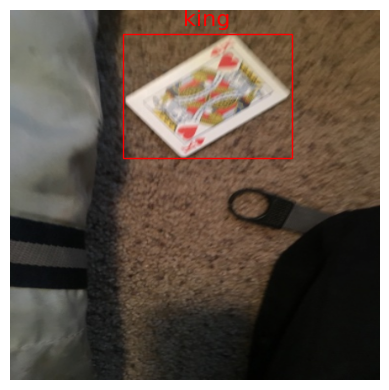

In [6]:
num = 89
visualize_normalsize(train_ds[num][0], train_ds[num][1])

In [7]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, **kwargs):
        super(CNNBlock, self).__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, bias = False, **kwargs)
        self.batchnorm = nn.BatchNorm2d(out_channels)
        self.lReLU = nn.LeakyReLU(0.1)

    def forward(self, X):
        X = self.conv(X)
        X = self.batchnorm(X)
        X = self.lReLU(X)
        return X
        
class Yolov1(nn.Module):
    def __init__(self, n_box = 2, grid_size = 7, in_channels = 3, num_classes = 1000, **kwargs):
        super(Yolov1, self).__init__()
        self.darknet = nn.Sequential(
            CNNBlock(in_channels=in_channels, out_channels=64, kernel_size = 7, stride = 2, padding = 3),
            nn.MaxPool2d(2, stride=2),
            
            CNNBlock(in_channels=64, out_channels=192, kernel_size = 3, stride = 2, padding = 1),
            nn.MaxPool2d(2, stride=2),
            
            CNNBlock(in_channels=192, out_channels=128, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=128, out_channels=256, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=256, out_channels=256, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=256, out_channels=512, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(2, stride=2),

            
            CNNBlock(in_channels=512, out_channels=256, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=256, out_channels=512, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=512, out_channels=256, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=256, out_channels=512, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=512, out_channels=256, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=256, out_channels=512, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=512, out_channels=256, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=256, out_channels=512, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=512, out_channels=512, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=512, out_channels=1024, kernel_size = 3, stride = 1, padding = 1),
            nn.MaxPool2d(2, stride = 2),

            CNNBlock(in_channels=1024, out_channels=512, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=512, out_channels=1024, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=1024, out_channels=512, kernel_size = 1, stride = 1, padding = 0),
            CNNBlock(in_channels=512, out_channels=1024, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=1024, out_channels=1024, kernel_size = 3, stride = 1, padding = 1),
            CNNBlock(in_channels=1024, out_channels=1024, kernel_size = 3, stride = 2, padding = 2),
            
            CNNBlock(in_channels=1024, out_channels=1024, kernel_size = 3, stride = 1, padding = 2),
            CNNBlock(in_channels=1024, out_channels=1024, kernel_size = 3, stride = 1, padding = 1),
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear((1024 * grid_size * grid_size), 4096),
            nn.Dropout1d(0.5),
            nn.LeakyReLU(0.1),
            nn.Linear(4096, grid_size*grid_size*(n_box*5 + num_classes))
        )
    def forward(self, X):
        X = self.darknet(X)
        return self.fc(X).float()

In [11]:
def check_for_nan_inf(tensor, name):
    if torch.isnan(tensor).any():
        print(f"{name} contains NaN values")
    if torch.isinf(tensor).any():
        print(f"{name} contains Inf values")

In [52]:
class YoloLoss(nn.Module):
    def __init__(self, C, S, B, lambda_noobj, lambda_coord):
        super(YoloLoss, self).__init__()
        self.C = C
        self.S = S
        self.B = B
        self.MSE = nn.MSELoss(reduction='sum')
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj
    def forward(self, y_pred, y_true):
        y_pred = y_pred.reshape(-1, self.S, self.S, self.C + self.B * 5)
        iou_1 = intersection_over_union(y_pred[..., self.C + 1: self.C + 5], y_true[..., self.C + 1: self.C + 5])
        iou_2 = intersection_over_union(y_pred[..., self.C + 6: self.C + 10], y_true[..., self.C + 6: self.C + 10])
        ious = torch.cat([iou_1.unsqueeze(0), iou_2.unsqueeze(0)], dim = 0)

        iou_max, bestbox = torch.max(ious, dim = 0)
        exists_box = y_true[..., self.C].unsqueeze(3)

        #box_coords loss
        box_pred = exists_box * (bestbox * y_pred[..., self.C + 6:self.C + 10] + (1 - bestbox) * y_pred[..., self.C + 1:self.C + 5])
        box_true = exists_box * y_pred[..., self.C + 1:self.C + 5]
        
        box_pred[..., 2:4] = torch.sign(box_pred[..., 2:4]) * torch.sqrt(torch.abs(box_pred[..., 2:4] + 1e-6))
        box_true[..., 2:4] = torch.sqrt(torch.abs(box_true[..., 2:4] + 1e-6))
        
        box_loss = self.MSE(torch.flatten(box_pred, end_dim = -2), torch.flatten(box_true, end_dim = -2))
        
        #object loss
        pred_box = ((1-bestbox) * y_pred[..., self.C:self.C+1] + bestbox * y_pred[..., self.C + 5:self.C + 6])
        obj_loss = self.MSE(torch.flatten(pred_box, end_dim = -2), torch.flatten(y_true[..., self.C:self.C+1]))
        

        #no_object loss
        no_obj_loss = self.MSE(
            torch.flatten((1 - exists_box) * y_pred[..., self.C:self.C+1], start_dim = 1), 
            torch.flatten((1 - exists_box) * y_true[..., self.C:self.C + 1], start_dim = 1)
        )

        no_obj_loss += self.MSE(
            torch.flatten((1 - exists_box) * y_pred[..., self.C + 5:self.C + 6], start_dim = 1), 
            torch.flatten((1 - exists_box) * y_true[..., self.C:self.C + 1], start_dim = 1)
        )

        #class loss
        class_loss = self.MSE(
            torch.flatten(exists_box * y_pred[..., :self.C], end_dim=-2,),
            torch.flatten(exists_box * y_true[..., :self.C], end_dim=-2,),
        )
        #print(box_loss * self.lambda_coord, obj_loss , no_obj_loss * self.lambda_noobj, class_loss)
        return box_loss * self.lambda_coord + obj_loss + no_obj_loss * self.lambda_noobj + class_loss

In [53]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = Yolov1(num_classes=6, n_box=2, grid_size=7).to(device)
loss_fn = YoloLoss(C = 6, B = 2, S = 7, lambda_coord=5, lambda_noobj=0.5)#.to(device)
lr = 2e-5
optimizer = torch.optim.Adam(params = model.parameters(), lr=lr, weight_decay=1e-5)


In [54]:
torch.set_anomaly_enabled(True)
epochs = 100
#lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer=optimizer, T_max = 1, eta_min = 1e-5)
for epoch in range(epochs):
    train_loop = tqdm(train_dataloader)
    train_loss = []
    for X, y in train_loop:
        optimizer.zero_grad()
        X = X.to(device)
        y = y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        loss.backward()
        train_loss.append(loss)
        optimizer.step()
        #lr_scheduler.step()
    print(f'Epochs: {epoch + 1}/{epochs}, Loss {sum(train_loss) / len(train_loss)}') #, LearningRate {lr_scheduler.get_last_lr()[0]}

100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:17<00:00,  1.21it/s]


Epochs: 1/100, Loss 104853.4765625


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:17<00:00,  1.22it/s]


Epochs: 2/100, Loss 25221.625


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:17<00:00,  1.21it/s]


...

Epochs: 98/100, Loss 21635.5546875


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:10<00:00,  2.05it/s]


Epochs: 99/100, Loss 21720.97265625


100%|██████████████████████████████████████████████████████████████████████████████████| 21/21 [00:10<00:00,  2.05it/s]


Epochs: 100/100, Loss 21708.4765625
